# YouTube Trending Videos — Part A: Data Preprocessing & EDA

**프로젝트**: YouTube 트렌딩 영상 데이터셋(USvideos.csv) 분석  
**목표**: 영상 조회수 예측 및 YouTube 영상 인기 요인 분석 (광고 수익 맥락)  
**담당**: Part A — 데이터 전처리 및 탐색적 데이터 분석(EDA)

## 출력 파일 목록
- `cleaned_USvideos.csv` — 전처리된 데이터셋 (Part B, C 팀원용)
- `fig1_views_distribution.png` — 조회수 분포 (Raw vs Log)
- `fig2_correlation.png` — 상관관계 히트맵
- `fig3_category_views.png` — 카테고리별 조회수 분석
- `fig4_time_heatmap_all.png` — 업로드 시간대별 조회수 히트맵 (전체)
- `fig5_time_heatmap_top3.png` — 상위 3개 카테고리 시간대 히트맵

---
## Task 1: Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import warnings

warnings.filterwarnings('ignore')

# 시각화 스타일 설정
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

# --- 데이터 로드 ---
df = pd.read_csv('../../dataset/USvideos.csv', encoding='utf-8')

# US_category_id.json에서 category_id → 카테고리명 매핑 딕셔너리 생성
with open('US_category_id.json', 'r', encoding='utf-8') as f:
    cat_data = json.load(f)

category_map = {
    int(item['id']): item['snippet']['title']
    for item in cat_data['items']
}

# --- 기본 정보 출력 ---
print('=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== First 5 Rows ===')
df.head()

=== Shape ===
(40949, 16)

=== Data Types ===
video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_time              object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
thumbnail_link            object
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
description               object
dtype: object

=== Missing Values ===
video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


---
## Task 2: Preprocessing

In [2]:
# Step 1: trending_date 날짜 변환 (형식: 'YY.DD.MM')
try:
    df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')
except Exception as e:
    print(f'[WARNING] trending_date 변환 오류: {e}')
    df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')

# Step 2: publish_time 날짜 변환
try:
    df['publish_time'] = pd.to_datetime(df['publish_time'], format='%Y-%m-%dT%H:%M:%S.%fZ')
except Exception as e:
    print(f'[WARNING] publish_time 변환 오류: {e}')
    df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')

# Step 3: publish_time에서 날짜/시간 정보 추출
df['publish_date']    = df['publish_time'].dt.date
df['publish_hour']    = df['publish_time'].dt.hour       # 0~23
df['publish_weekday'] = df['publish_time'].dt.dayofweek  # 0=월요일 ~ 6=일요일

# Step 4: category_id → 카테고리명 매핑
df['category'] = df['category_id'].map(category_map)

# Step 5: category가 null인 행 제거 (JSON에 없는 category_id)
df = df.dropna(subset=['category'])

# Step 6: 중복 제거 — video_id별 views 최대값 행만 유지
# 이유: 같은 영상이 여러 날 트렌딩에 오를 수 있으며, 최종 최대 조회수가 실제 인기를 대표
before_dedup = len(df)
df = df.sort_values('views', ascending=False).drop_duplicates(subset='video_id', keep='first')
after_dedup = len(df)
print(f'중복 제거 전: {before_dedup}행 → 중복 제거 후: {after_dedup}행 (제거: {before_dedup - after_dedup}행)')

# Step 7: trending_lag 계산 (업로드일 → 첫 트렌딩일까지 소요 일수)
# 먼저 원본 데이터에서 video_id별 최초 트렌딩 날짜를 구해야 하므로,
# 중복 제거 전 데이터를 활용하여 min trending_date를 계산
df_full = pd.read_csv('../../dataset/USvideos.csv', encoding='utf-8')
try:
    df_full['trending_date'] = pd.to_datetime(df_full['trending_date'], format='%y.%d.%m')
    df_full['publish_time']  = pd.to_datetime(df_full['publish_time'],  format='%Y-%m-%dT%H:%M:%S.%fZ')
except Exception as e:
    print(f'[WARNING] 재로드 변환 오류: {e}')
    df_full['trending_date'] = pd.to_datetime(df_full['trending_date'], errors='coerce')
    df_full['publish_time']  = pd.to_datetime(df_full['publish_time'],  errors='coerce')

df_full['publish_date'] = df_full['publish_time'].dt.date

# video_id별 첫 트렌딩 날짜
first_trending = df_full.groupby('video_id')['trending_date'].min().reset_index()
first_trending.columns = ['video_id', 'first_trending_date']

# video_id별 트렌딩 일수 (unique trending_date 수)
days_trending = df_full.groupby('video_id')['trending_date'].nunique().reset_index()
days_trending.columns = ['video_id', 'days_on_trending']

# 중복 제거된 df에 병합
df = df.merge(first_trending, on='video_id', how='left')
df = df.merge(days_trending,  on='video_id', how='left')

# trending_lag 계산 (날짜 차이를 일 단위로)
df['publish_date_dt']      = pd.to_datetime(df['publish_date'])
df['trending_lag']         = (df['first_trending_date'] - df['publish_date_dt']).dt.days

# trending_lag < 0 제거 (업로드일보다 트렌딩일이 앞선 데이터 오류)
before_lag = len(df)
df = df[df['trending_lag'] >= 0]
print(f'trending_lag < 0 제거 전: {before_lag}행 → 제거 후: {len(df)}행')

# Step 9~11: 로그 변환 (오른쪽 꼬리 분포 정규화)
# log1p 사용 이유: views=0인 경우 log(0) = -inf 오류 방지
df['log_views']         = np.log1p(df['views'])
df['log_likes']         = np.log1p(df['likes'])
df['log_comment_count'] = np.log1p(df['comment_count'])

# Step 12: 정제된 데이터 저장
output_cols = [
    'video_id', 'title', 'category', 'views', 'log_views',
    'likes', 'log_likes', 'dislikes', 'comment_count', 'log_comment_count',
    'publish_hour', 'publish_weekday', 'trending_lag', 'days_on_trending',
    'tags', 'comments_disabled', 'ratings_disabled'
]
df[output_cols].to_csv('../../dataset/cleaned_USvideos.csv', index=False, encoding='utf-8')

print(f'\n최종 데이터셋 저장 완료: {len(df)}행 × {len(output_cols)}열')
df[output_cols].head()

중복 제거 전: 40949행 → 중복 제거 후: 6351행 (제거: 34598행)


trending_lag < 0 제거 전: 6351행 → 제거 후: 6350행

최종 데이터셋 저장 완료: 6350행 × 17열


,video_id,title,category,views,log_views,likes,log_likes,dislikes,comment_count,log_comment_count,publish_hour,publish_weekday,trending_lag,days_on_trending,tags,comments_disabled,ratings_disabled
0,VYOjWnS4cMY,Childish Gambino - This Is America (Official V...,Music,225211923,19.232552,5023450,15.429628,343541,517232,13.156249,4,6,2,25,"Childish Gambino|""Rap""|""This Is America""|""mcDJ...",False,False
1,FlsCjmMhFmw,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,Entertainment,149376127,18.821978,3093544,14.944828,1643059,810698,13.605652,17,2,1,8,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",False,False
2,ffxKSjUwKdU,Ariana Grande - No Tears Left To Cry,Music,148689896,18.817373,3094021,14.944982,129502,242039,12.396858,4,4,1,20,"Ariana|""Grande""|""No""|""Tears""|""Left""|""To""|""Cry""...",False,False
3,zEf423kYfqk,"Becky G, Natti Natasha - Sin Pijama (Official ...",Music,139334502,18.752388,1425496,14.170031,119798,83941,11.337881,10,4,1,20,"Becky G|""Natti Natasha""|""Natti Natasha Music""|...",False,False
4,7C2z4GqqS5E,BTS (방탄소년단) 'FAKE LOVE' Official MV,Music,123010920,18.627784,5613827,15.540743,206892,1228655,14.021431,9,4,1,14,"BIGHIT|""빅히트""|""방탄소년단""|""BTS""|""BANGTAN""|""방탄""|""FAK...",False,False


---
## Task 3: EDA — Views Distribution

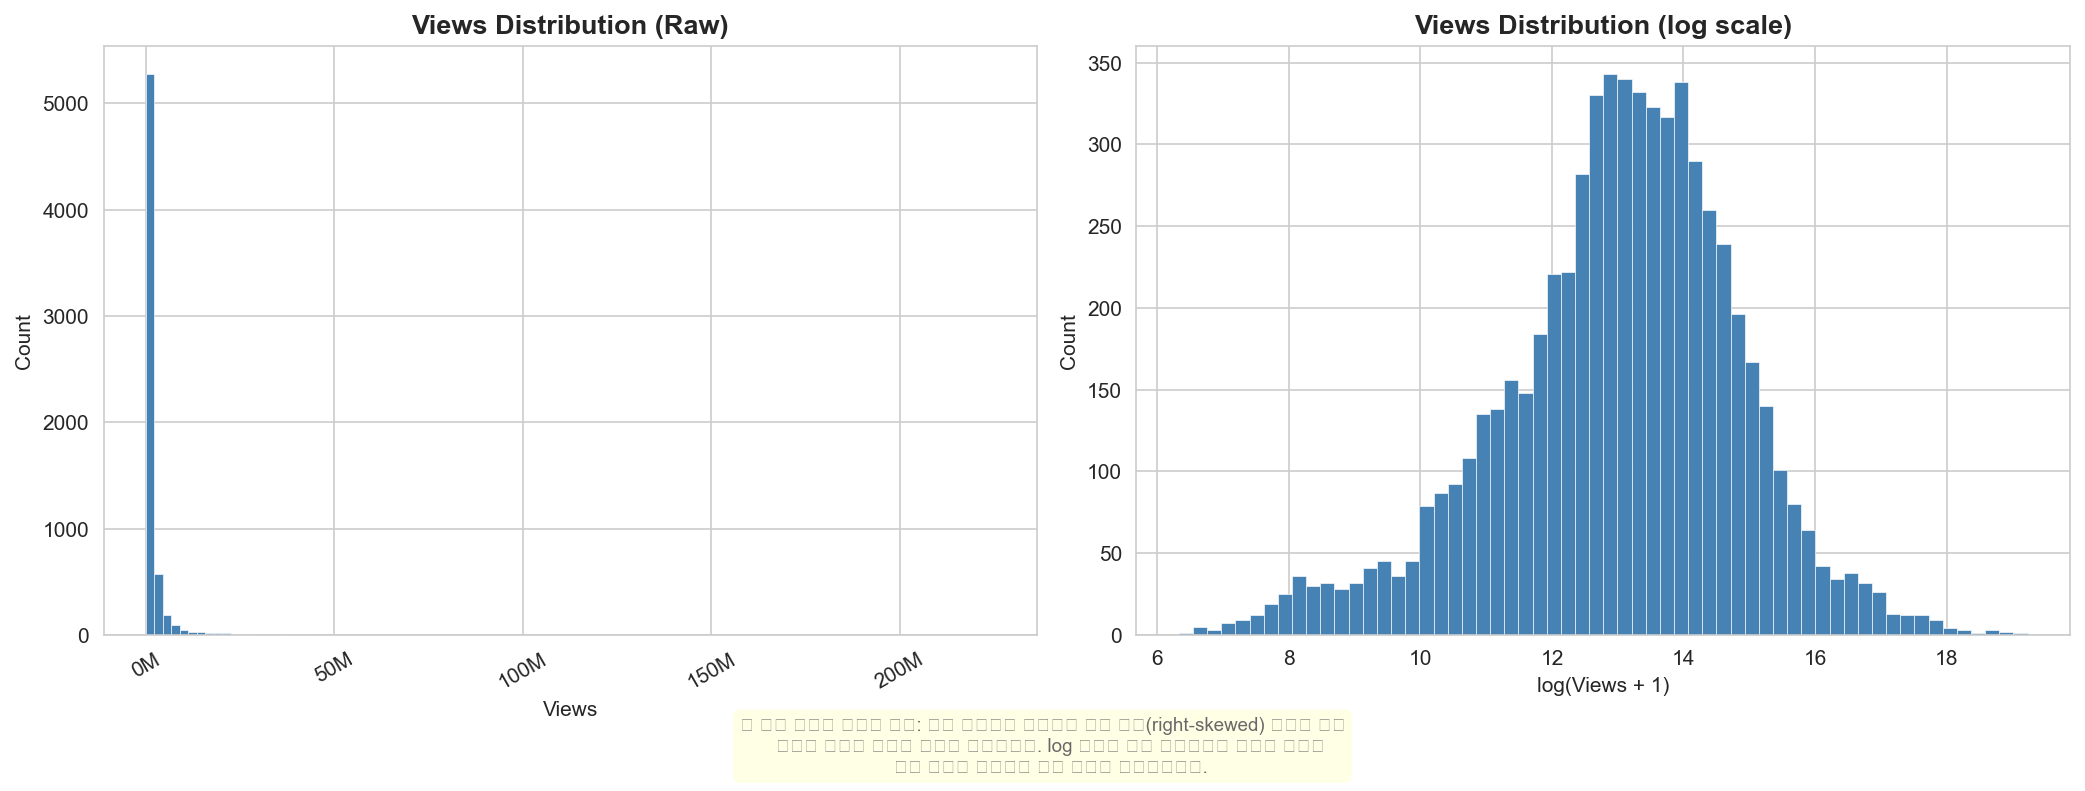

fig1_views_distribution.png 저장 완료


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 원시 조회수 분포
axes[0].hist(df['views'], bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Views Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Count')
# x축 단위를 읽기 쉽게 포맷
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].tick_params(axis='x', rotation=30)

# 오른쪽: 로그 변환 조회수 분포
axes[1].hist(df['log_views'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_title('Views Distribution (log scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Views + 1)')
axes[1].set_ylabel('Count')

# 로그 변환이 필요한 이유를 텍스트로 설명
fig.text(
    0.5, -0.04,
    '※ 로그 변환이 필요한 이유: 원시 조회수는 극단적인 우측 편향(right-skewed) 분포를 보여\n'
    '   소수의 초대형 영상이 분포를 왜곡합니다. log 변환을 통해 정규분포에 가깝게 만들어\n'
    '   회귀 모델의 안정성과 예측 성능을 향상시킵니다.',
    ha='center', fontsize=9, color='dimgray',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()
plt.savefig('fig1_views_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig1_views_distribution.png 저장 완료')

---
## Task 4: EDA — Correlation Heatmap

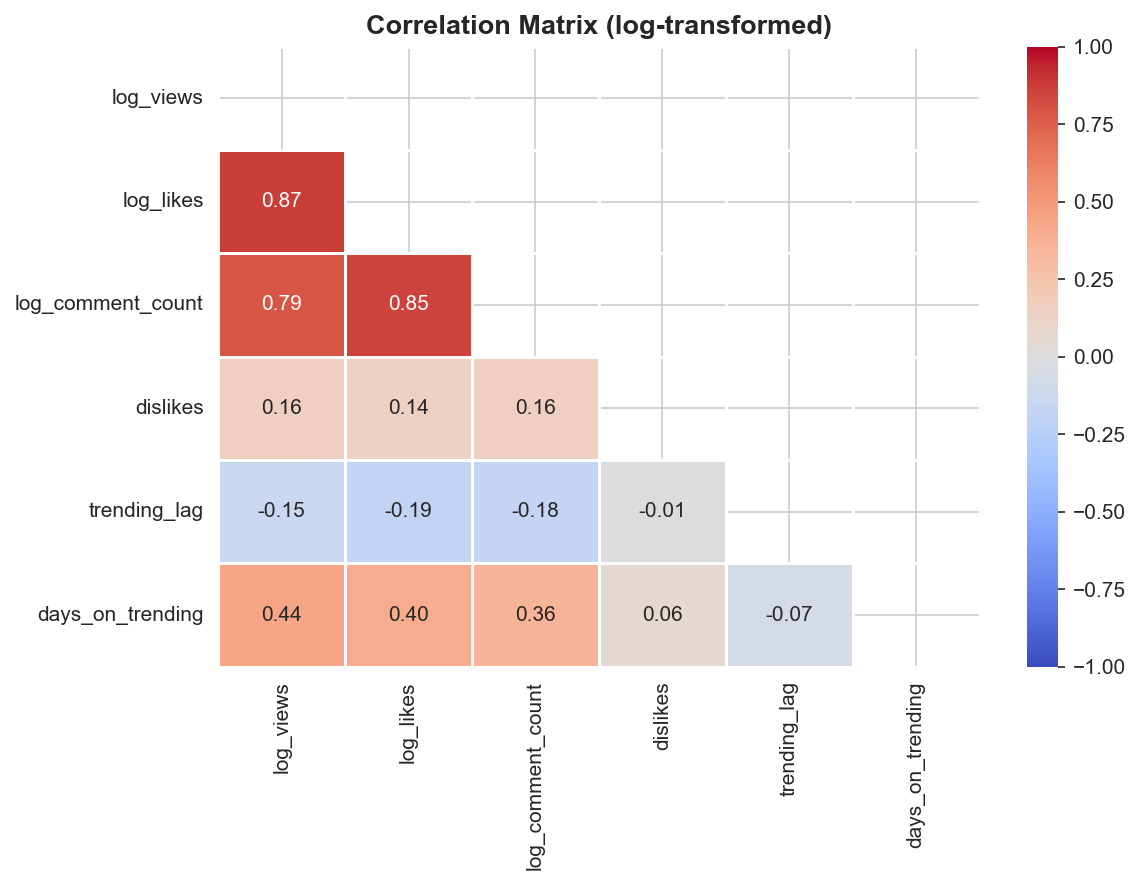

fig2_correlation.png 저장 완료

▶ log_views와 가장 높은 상관관계를 보이는 상위 3개 변수:
  log_likes: 0.8700
  log_comment_count: 0.7888
  days_on_trending: 0.4385


In [4]:
corr_cols = ['log_views', 'log_likes', 'log_comment_count', 'dislikes', 'trending_lag', 'days_on_trending']
corr_matrix = df[corr_cols].corr()

# 상삼각 마스크 (하삼각만 표시)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax
)
ax.set_title('Correlation Matrix (log-transformed)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig2_correlation.png 저장 완료')

# log_views와의 상관관계 상위 3개 변수 출력
top3_corr = (
    corr_matrix['log_views']
    .drop('log_views')
    .abs()
    .sort_values(ascending=False)
    .head(3)
)
print('\n▶ log_views와 가장 높은 상관관계를 보이는 상위 3개 변수:')
for var, val in top3_corr.items():
    actual_corr = corr_matrix.loc[var, 'log_views']
    print(f'  {var}: {actual_corr:.4f}')

---
## Task 5: EDA — Category Analysis (Hypothesis H1)

**H1**: "조회수의 분포와 패턴은 카테고리별로 구조적으로 다르다"

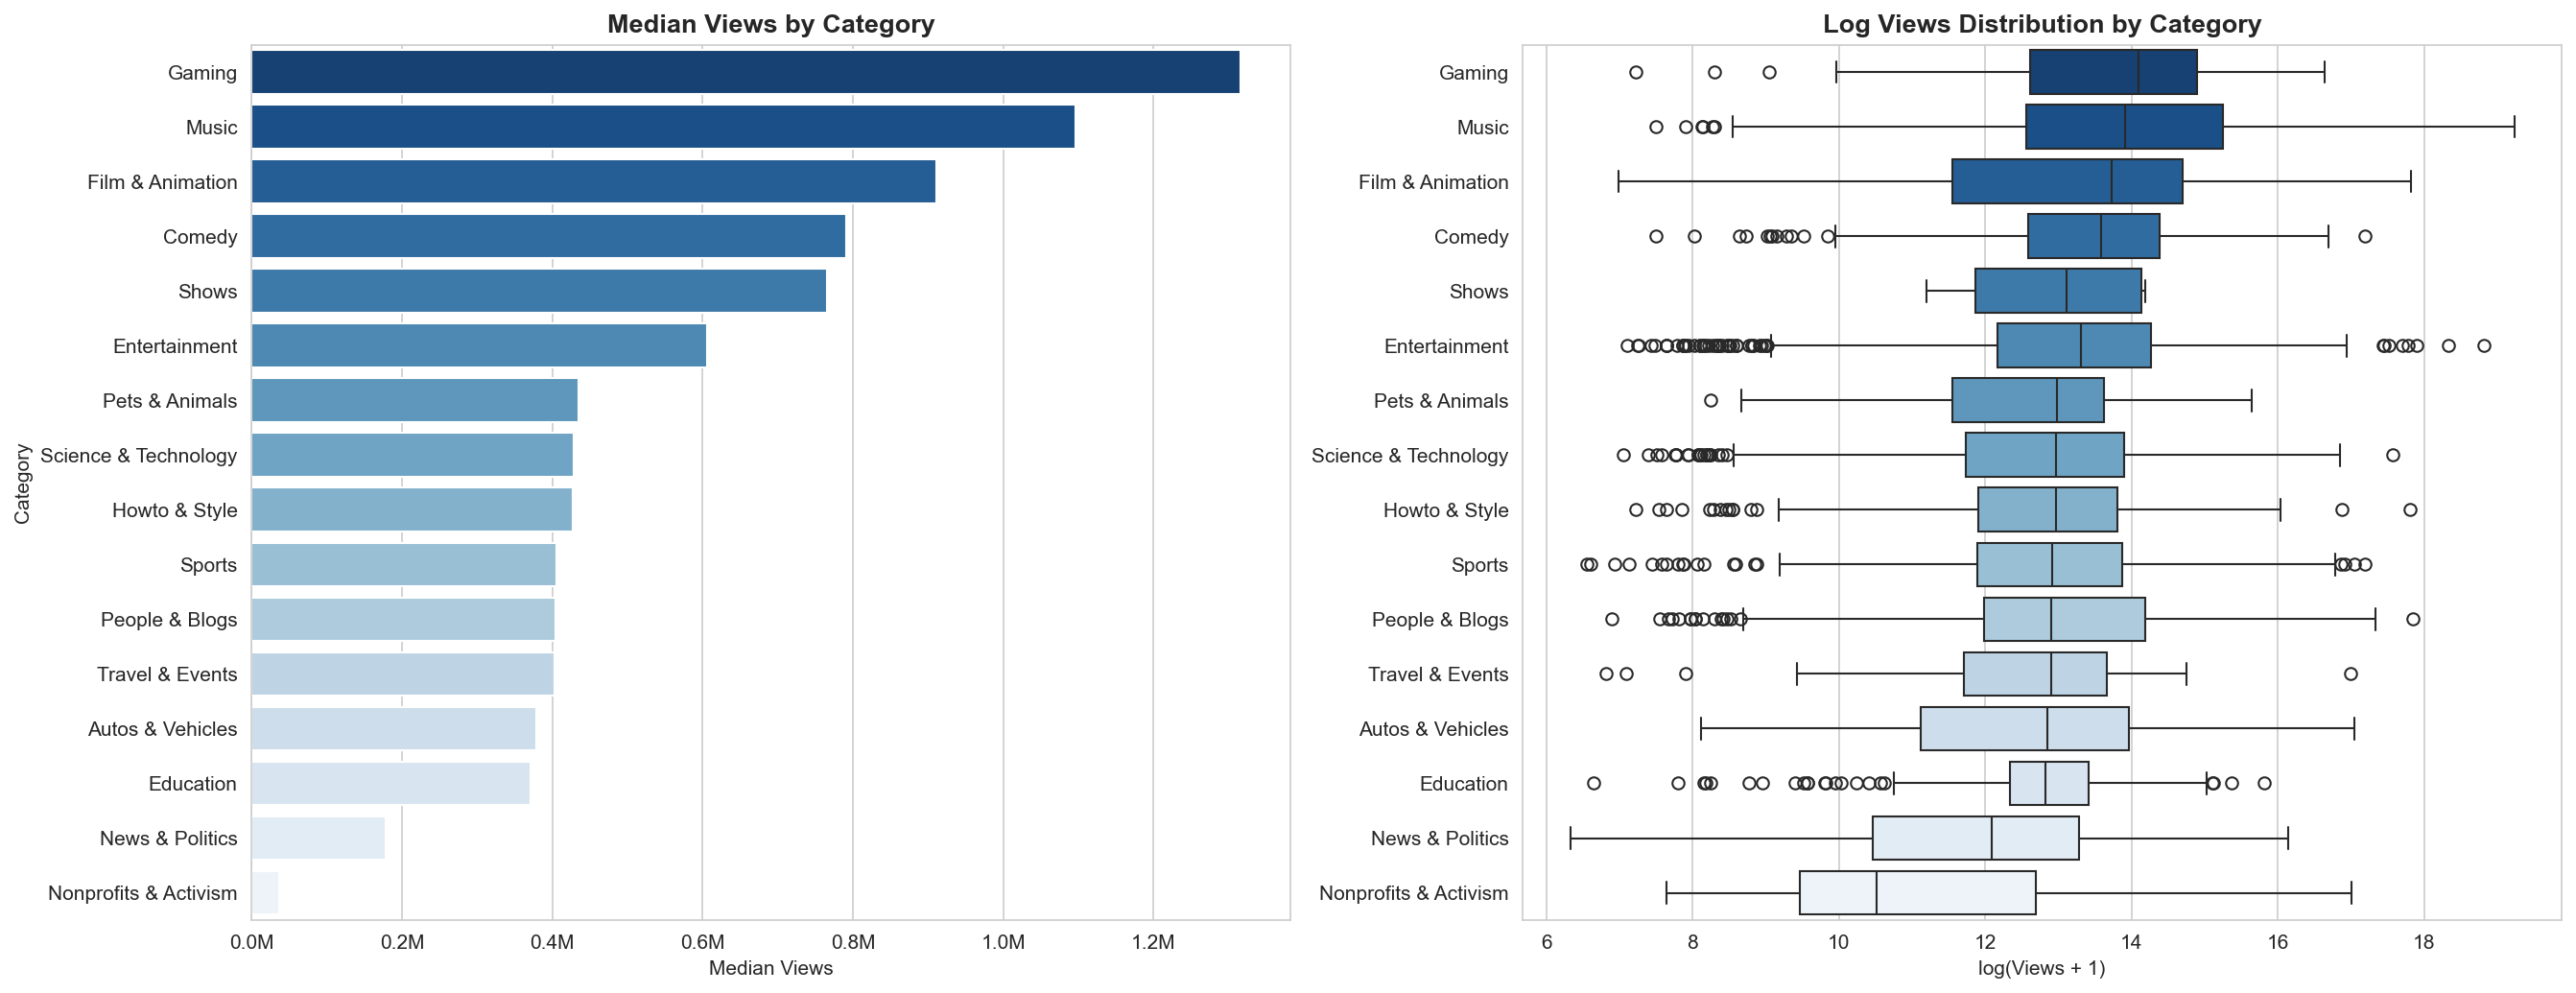

fig3_category_views.png 저장 완료

▶ 중앙값 조회수 상위 3개 카테고리:
  Gaming: 1,316,002
  Music: 1,096,158
  Film & Animation: 910,970

▶ 중앙값 조회수 하위 3개 카테고리:
  Education: 370,450
  News & Politics: 178,852
  Nonprofits & Activism: 36,964


In [5]:
# 카테고리별 중앙값 조회수 계산 (평균 대신 중앙값 사용: 이상치에 강건)
cat_median = df.groupby('category')['views'].median().sort_values(ascending=False)
category_order = cat_median.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 왼쪽: 카테고리별 중앙값 조회수 수평 막대 그래프
sns.barplot(
    x=cat_median.values,
    y=cat_median.index,
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title('Median Views by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median Views')
axes[0].set_ylabel('Category')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# 오른쪽: 카테고리별 log_views 박스플롯 (왼쪽과 동일한 카테고리 순서)
sns.boxplot(
    data=df,
    x='log_views',
    y='category',
    order=category_order,
    palette='Blues_r',
    ax=axes[1]
)
axes[1].set_title('Log Views Distribution by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Views + 1)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('fig3_category_views.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig3_category_views.png 저장 완료')

print('\n▶ 중앙값 조회수 상위 3개 카테고리:')
for cat in category_order[:3]:
    print(f'  {cat}: {cat_median[cat]:,.0f}')

print('\n▶ 중앙값 조회수 하위 3개 카테고리:')
for cat in category_order[-3:]:
    print(f'  {cat}: {cat_median[cat]:,.0f}')

---
## Task 6: EDA — Upload Time Analysis (Hypothesis H2)

**H2**: "업로드 시간이 조회수에 영향을 미치며, 최적 시간대는 카테고리마다 다르다"

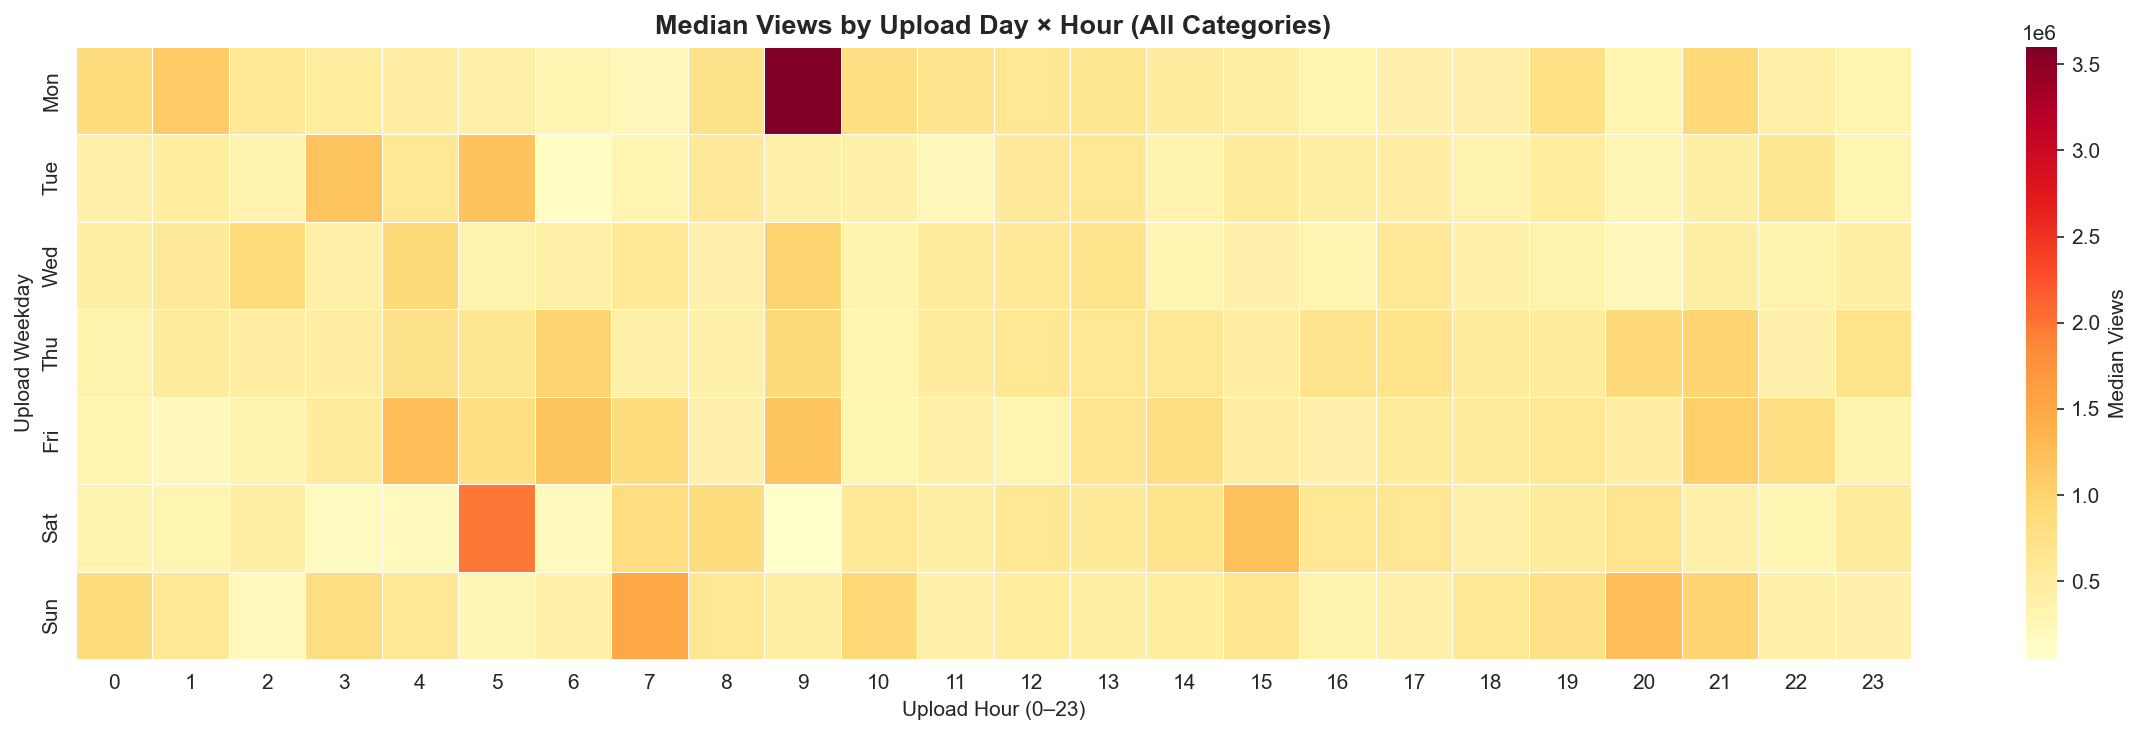

fig4_time_heatmap_all.png 저장 완료


In [6]:
# 요일 레이블 (0=Mon ~ 6=Sun)
weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 전체 데이터 기준 요일×시간 피벗 테이블 (중앙값 조회수)
pivot_all = df.pivot_table(
    values='views',
    index='publish_weekday',
    columns='publish_hour',
    aggfunc='median'
)
# 인덱스를 요일 이름으로 변환
pivot_all.index = [weekday_labels[i] for i in pivot_all.index]

# Plot 1: 전체 히트맵
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot_all,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Median Views'}
)
ax.set_title('Median Views by Upload Day × Hour (All Categories)', fontsize=13, fontweight='bold')
ax.set_xlabel('Upload Hour (0–23)')
ax.set_ylabel('Upload Weekday')
plt.tight_layout()
plt.savefig('fig4_time_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig4_time_heatmap_all.png 저장 완료')

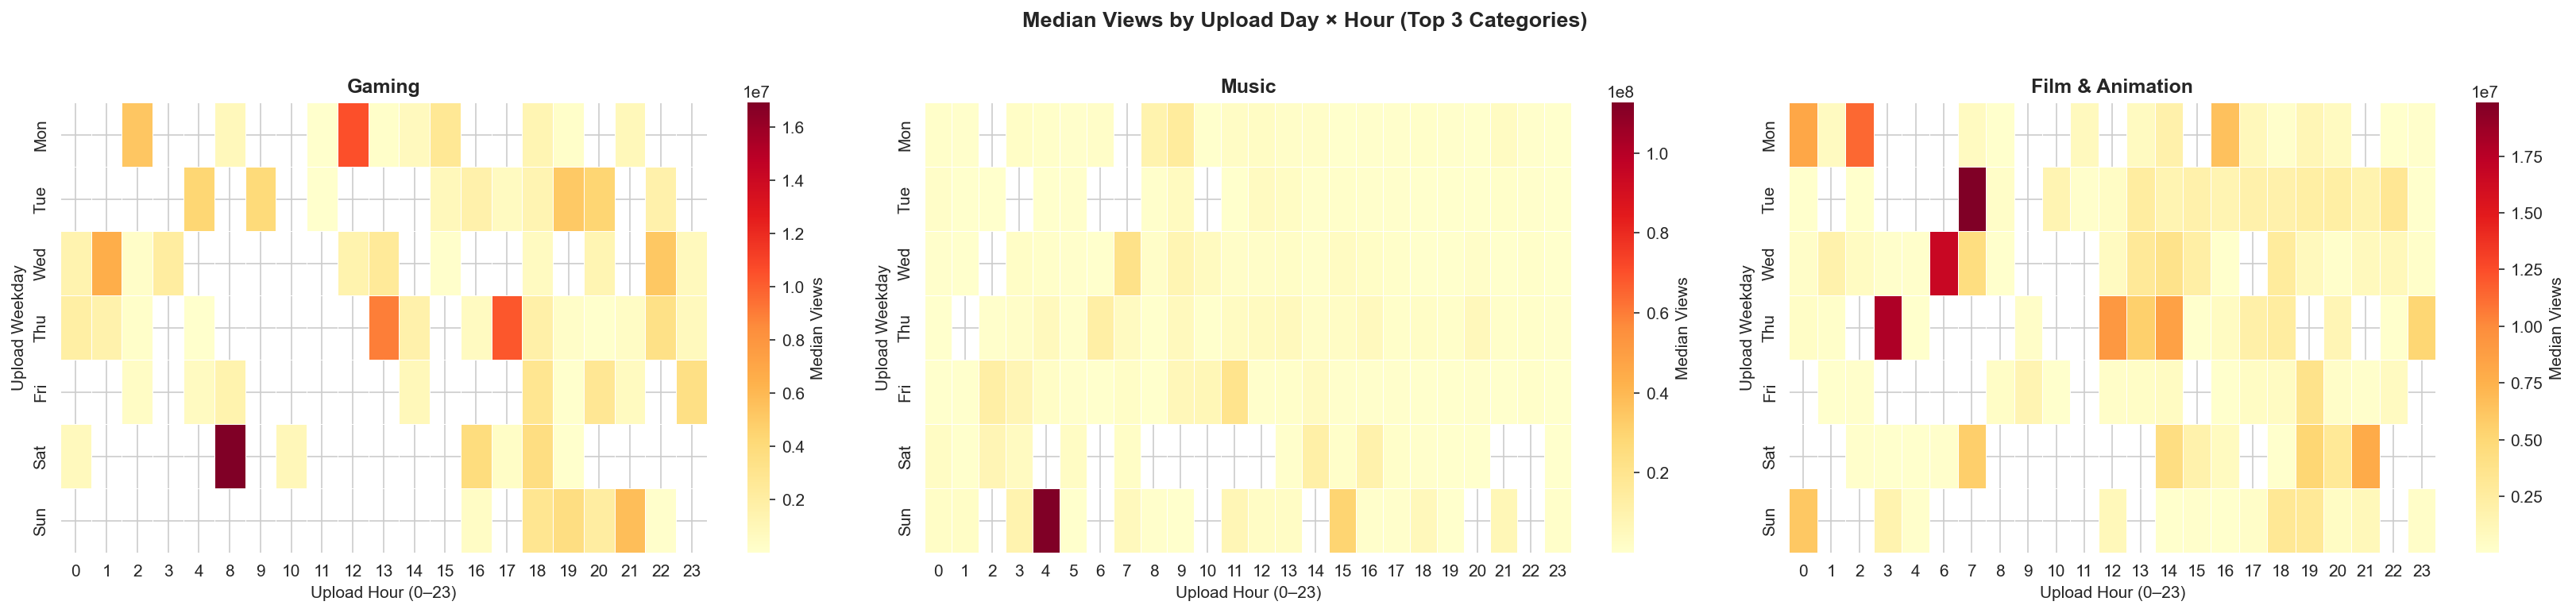

fig5_time_heatmap_top3.png 저장 완료


In [7]:
# Plot 2: 상위 3개 카테고리 히트맵
top3_categories = category_order[:3]  # Task 5에서 계산된 중앙값 순위 활용

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, cat in zip(axes, top3_categories):
    df_cat = df[df['category'] == cat]
    pivot_cat = df_cat.pivot_table(
        values='views',
        index='publish_weekday',
        columns='publish_hour',
        aggfunc='median'
    )
    # 전체 요일(0~6) 인덱스가 없는 경우 reindex로 채움
    pivot_cat = pivot_cat.reindex(range(7))
    pivot_cat.index = weekday_labels

    sns.heatmap(
        pivot_cat,
        cmap='YlOrRd',
        linewidths=0.3,
        linecolor='white',
        ax=ax,
        cbar_kws={'label': 'Median Views'}
    )
    ax.set_title(cat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Upload Hour (0–23)')
    ax.set_ylabel('Upload Weekday')

plt.suptitle('Median Views by Upload Day × Hour (Top 3 Categories)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_time_heatmap_top3.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig5_time_heatmap_top3.png 저장 완료')

---
## Task 7: EDA 요약 및 마무리

In [8]:
# 최종 데이터셋 크기 확인
df_clean = pd.read_csv('../../dataset/cleaned_USvideos.csv')
print(f'정제된 데이터셋 크기: {df_clean.shape[0]}행 × {df_clean.shape[1]}열')

정제된 데이터셋 크기: 6350행 × 17열


## EDA 종합 요약

### 데이터셋 크기 (전처리 후)
- 중복 제거, trending_lag 음수 제거, 카테고리 매핑 후 최종 데이터셋 행/열 수는 위 셀에서 확인

### 주요 EDA 발견사항 (Top 3)

1. **조회수의 극심한 우측 편향**: 소수의 바이럴 영상이 수억 뷰를 기록하며 분포를 왜곡함. 로그 변환 후 분포가 정규분포에 가까워져 예측 모델 안정성 향상 가능.

2. **카테고리별 조회수 차이 (H1 지지)**: Music, Entertainment 등의 카테고리는 중앙값 조회수가 현저히 높으며, News & Politics, Nonprofits & Activism 등은 상대적으로 낮음. 카테고리는 조회수 예측의 핵심 특징이 될 가능성 높음.

3. **좋아요 수(log_likes)와 조회수의 강한 양의 상관관계**: log_likes가 log_views와 가장 높은 상관관계를 보이며, 참여도(engagement)가 조회수를 예측하는 가장 강력한 지표임을 시사.

### 조회수 예측에 중요한 변수

| 변수 | 근거 |
|------|------|
| `log_likes` | 조회수와 가장 높은 상관관계 |
| `log_comment_count` | 댓글 참여도도 조회수와 강한 관계 |
| `category` | 카테고리 간 중앙값 조회수 차이가 매우 큼 |
| `days_on_trending` | 트렌딩 지속일이 길수록 노출 기회 증가 |
| `publish_hour` / `publish_weekday` | 업로드 시간대에 따라 초기 조회수 패턴 다름 (H2) |